# Laboratorio 2

## Desarrollo de una herramienta analítica usando paquetes especializados para análisis de datos en Python

Para el desarrollo de esta actividad puedes utilizar cualquier librería externa. Te recomendamos leer por completo el enunciado del laboratorio antes de comenzar, de forma que tengas claro el propósito global de la actividad y puedas desarrollar tu solución apuntando a él desde el inicio.

Al desarrollar este laboratorio pondrás a prueba tus habilidades para:

1. Identificar y abordar preguntas de negocio y de *analytics*.
2. Leer datos desde archivos y almacenarlos utilizando métodos de librerías especializadas.
3. Explorar, modificar, limpiar y unir objetos tablas de datos.
4. Implementar análisis combinando métricas descriptivas, visualización, filtrado y agrupación.
5. Implementar análisis basado en modelos estadísticos o de *machine learning*.

##  Contexto: desigualdad y factores de éxito en pruebas Saber 11 en Colombia

El ICFES es el Instituto Colombiano para el Fomento de la Educación Superior y está adscrito al Ministerio de Educación a nivel nacional. Como parte de sus funciones, el ICFES administra las pruebas Saber 11, las cuales evalúan a todos los estudiantes del país al final de su educación secundaria. El examen contiene preguntas que evalúan una variedad de áreas del conocimiento (ej., matemáticas, física, inglés, etc.) y se lleva a cabo dos veces al año, ajustándose a los diferentes calendarios académicos que siguen las instituciones educativas. Al momento de inscribirse a las pruebas, los estudiantes diligencian un formulario que recoge información sociodemográfica y relacionada con la institución a la que pertenecen. El fin es obtener información con respecto al desempeño de los estudiantes en la prueba y de sus características.

Al igual que otros países de la región, Colombia tiene grandes retos en términos de desigualdad, particularmente en el contexto de educación primaria y secundaria. Por esta razón, para el Estado colombiano es muy valioso el amplio registro de datos que el ICFES genera alrededor de las pruebas Saber 11, pues con ellos se pueden generar análisis sobre la calidad de la educación en el país y eventualmente dar lugar a recomendaciones sobre políticas públicas. En particular, la problemática a abordar en este caso de estudio es la desigualdad y factores de éxito en las pruebas Saber 11. 

Los objetivos de este caso de estudio son:

* Entender el contenido de los archivos de datos proporcionados sobre las pruebas Saber 11, generar un reporte acerca de sus características principales y seleccionar las partes de dicho contenido que podrían ser relevantes para el análisis.


* Identificar características de las variables de interés y relaciones entre ellas, por ejemplo, a través de agrupación, visualizaciones y estadísticas descriptivas.


* Proponer un modelo que busque relacionar las variables de interés con el desempeño de los estudiantes y concluir acerca de los posibles hallazgos que se podrían reportar para el *stakeholder*.


* Generar una herramienta que permita a un usuario interactuar con alguno de los parámetros del análisis realizado de forma relevante en el contexto del problema.

## Fase 1: obtener e inspeccionar archivos

En esta fase te harás una idea general del contenido de los datos y generarás un reporte al respecto (ej., imprimiendo mensajes, presentando tablas de resumen, etc.). Además, seleccionarás un segmento de los datos que consideres útil para realizar tu análisis.

Pautas generales:

* Utilizar una librería especializada para leer los archivos de datos y agregarlos según sea necesario (ej., utilizando los métodos `append` o `concat` si eliges cargarlos utilizando la librería `pandas`).
* Inspeccionar el archivo a partir de sus encabezados, columnas y descripciones de las variables según su tipo (ej., numéricas, categóricas).
* Declarar una estructura de datos (ej., una lista) para almacenar un subconjunto de variables que puedan ser relevantes para la problemática de interés.

Preguntas guía:

* ¿Qué dimensiones tienen los datos?
* ¿Con cuántos años y periodos de evaluación se cuenta?
* ¿Cuáles variables pueden ser de interés para la problemática planteada?
* ¿Qué porcentaje de datos faltantes o no válidos hay en las columnas de interés? ¿Qué planteas para manejarlos?

In [130]:
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [131]:
data1=pd.read_csv("Saber_11°_2020-1_20250928.csv")
data2=pd.read_csv("Saber_11°_2020-2_20250928.csv")

df = pd.concat([data1, data2], ignore_index=True)

print("Dimensiones:", df.shape)
print("Columnas:", df.columns[:15])  # primeras 15
df.info()
df.isnull().mean().sort_values(ascending=False).head(20)


Dimensiones: (520307, 81)
Columnas: Index(['ESTU_TIPODOCUMENTO', 'ESTU_NACIONALIDAD', 'ESTU_GENERO',
       'ESTU_FECHANACIMIENTO', 'PERIODO', 'ESTU_CONSECUTIVO',
       'ESTU_ESTUDIANTE', 'ESTU_PAIS_RESIDE', 'ESTU_TIENEETNIA',
       'ESTU_DEPTO_RESIDE', 'ESTU_COD_RESIDE_DEPTO', 'ESTU_MCPIO_RESIDE',
       'ESTU_COD_RESIDE_MCPIO', 'FAMI_ESTRATOVIVIENDA', 'FAMI_PERSONASHOGAR'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520307 entries, 0 to 520306
Data columns (total 81 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   ESTU_TIPODOCUMENTO             520307 non-null  object 
 1   ESTU_NACIONALIDAD              520307 non-null  object 
 2   ESTU_GENERO                    520298 non-null  object 
 3   ESTU_FECHANACIMIENTO           520307 non-null  object 
 4   PERIODO                        520307 non-null  object 
 5   ESTU_CONSECUTIVO               520307 non-null  object

COLE_BILINGUE                    0.164561
ESTU_NSE_INDIVIDUAL              0.056467
ESTU_INSE_INDIVIDUAL             0.056467
FAMI_COMECEREALFRUTOSLEGUMBRE    0.041919
FAMI_TIENECOMPUTADOR             0.041545
FAMI_TRABAJOLABORPADRE           0.040643
FAMI_TIENEAUTOMOVIL              0.037024
ESTU_TIPOREMUNERACION            0.036717
FAMI_TRABAJOLABORMADRE           0.036630
FAMI_TIENECONSOLAVIDEOJUEGOS     0.036380
FAMI_TIENEHORNOMICROOGAS         0.035708
FAMI_TIENEMOTOCICLETA            0.035627
FAMI_ESTRATOVIVIENDA             0.035575
ESTU_HORASSEMANATRABAJA          0.035371
FAMI_SITUACIONECONOMICA          0.034141
FAMI_TIENELAVADORA               0.033940
FAMI_CUARTOSHOGAR                0.033207
FAMI_TIENESERVICIOTV             0.032640
FAMI_COMECARNEPESCADOHUEVO       0.032367
FAMI_PERSONASHOGAR               0.031866
dtype: float64

In [132]:
# Lista de variables seleccionadas
variables_seleccionadas = [
    "FAMI_ESTRATOVIVIENDA",
    "FAMI_EDUCACIONPADRE",
    "FAMI_EDUCACIONMADRE",
    "FAMI_TIENEINTERNET",
    "FAMI_TIENECOMPUTADOR",
    "COLE_NATURALEZA",
    "COLE_AREA_UBICACION",
    "COLE_JORNADA",
    "ESTU_NSE_INDIVIDUAL",
    "ESTU_TIENEETNIA",
    "FAMI_NUMLIBROS",
    "FAMI_TIENEAUTOMOVIL",
    "FAMI_PERSONASHOGAR",
    "COLE_BILINGUE",
    "COLE_CALENDARIO",
    "ESTU_GENERO",
    "ESTU_HORASSEMANATRABAJA",
    "PUNT_GLOBAL"
    
 # nuestra variable objetivo
]

# Crear un DataFrame reducido
df_reducido = df[variables_seleccionadas].copy()

# Revisar el tamaño y primeras filas
print("Dimensiones:", df_reducido.shape)
print(df_reducido.head())


Dimensiones: (520307, 18)
  FAMI_ESTRATOVIVIENDA                   FAMI_EDUCACIONPADRE  \
0            Estrato 1                   Primaria incompleta   
1                  NaN                                   NaN   
2            Estrato 1  Secundaria (Bachillerato) incompleta   
3            Estrato 1        Técnica o tecnológica completa   
4            Estrato 6        Educación profesional completa   

                    FAMI_EDUCACIONMADRE FAMI_TIENEINTERNET  \
0                   Primaria incompleta                 No   
1                                   NaN                NaN   
2  Secundaria (Bachillerato) incompleta                 No   
3        Educación profesional completa                 Si   
4    Secundaria (Bachillerato) completa                 Si   

  FAMI_TIENECOMPUTADOR COLE_NATURALEZA COLE_AREA_UBICACION COLE_JORNADA  \
0                   No         OFICIAL              URBANO        NOCHE   
1                  NaN      NO OFICIAL              URBANO     SAB

In [133]:
# Variables categóricas seleccionadas
categoricas = [
    
    "FAMI_ESTRATOVIVIENDA",
    "FAMI_EDUCACIONPADRE",
    "FAMI_EDUCACIONMADRE",
    "FAMI_TIENEINTERNET",
    "FAMI_TIENECOMPUTADOR",
    "COLE_NATURALEZA",
    "COLE_AREA_UBICACION",
    "COLE_JORNADA",
    "ESTU_NSE_INDIVIDUAL",
    "ESTU_TIENEETNIA",
    "FAMI_NUMLIBROS",
    "FAMI_TIENEAUTOMOVIL",
    "FAMI_PERSONASHOGAR",
    "COLE_BILINGUE",
    "COLE_CALENDARIO",
    "ESTU_GENERO",
    "ESTU_HORASSEMANATRABAJA",
    "PUNT_GLOBAL"  # nuestra variable objetivo

]

# Mostrar promedios de puntaje global por categoría
for var in categoricas:
    print(f"\n>>> {var}")
    print(df_reducido.groupby(var)["PUNT_GLOBAL"].mean())

# Variables numéricas
numericas = ["FAMI_PERSONASHOGAR", "ESTU_NSE_INDIVIDUAL"]

print("\n>>> Correlaciones numéricas con PUNT_GLOBAL:")
print(df_reducido[numericas + ["PUNT_GLOBAL"]].corr()["PUNT_GLOBAL"].sort_values(ascending=False))



>>> FAMI_ESTRATOVIVIENDA
FAMI_ESTRATOVIVIENDA
Estrato 1      236.955371
Estrato 2      250.468003
Estrato 3      262.842881
Estrato 4      276.773974
Estrato 5      282.087484
Estrato 6      283.352693
Sin Estrato    210.097161
Name: PUNT_GLOBAL, dtype: float64

>>> FAMI_EDUCACIONPADRE
FAMI_EDUCACIONPADRE
Educación profesional completa          278.845206
Educación profesional incompleta        273.571957
Ninguno                                 215.708859
No Aplica                               254.007874
No sabe                                 253.532162
Postgrado                               312.774671
Primaria completa                       237.130850
Primaria incompleta                     232.389388
Secundaria (Bachillerato) completa      250.589050
Secundaria (Bachillerato) incompleta    241.745454
Técnica o tecnológica completa          268.663332
Técnica o tecnológica incompleta        257.744073
Name: PUNT_GLOBAL, dtype: float64

>>> FAMI_EDUCACIONMADRE
FAMI_EDUCACIONMADRE
E

/var/folders/09/7m8tm9612zg736zrjcvhm_000000gn/T/ipykernel_768/926203037.py:34: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  print(df_reducido[numericas + ["PUNT_GLOBAL"]].corr()["PUNT_GLOBAL"].sort_values(ascending=False))


In [134]:
import pandas as pd

# Revisar tipos de columnas
print("Tipos de datos en el DataFrame:")
print(df_reducido.dtypes)

# Revisión de valores únicos por columna (solo para las que son object o string-like)
for col in df_reducido.columns:
    if df_reducido[col].dtype == "object" or df_reducido[col].dtype == "string":
        print(f"\n--- {col} ---")
        print(df_reducido[col].unique())


Tipos de datos en el DataFrame:
FAMI_ESTRATOVIVIENDA        object
FAMI_EDUCACIONPADRE         object
FAMI_EDUCACIONMADRE         object
FAMI_TIENEINTERNET          object
FAMI_TIENECOMPUTADOR        object
COLE_NATURALEZA             object
COLE_AREA_UBICACION         object
COLE_JORNADA                object
ESTU_NSE_INDIVIDUAL        float64
ESTU_TIENEETNIA             object
FAMI_NUMLIBROS              object
FAMI_TIENEAUTOMOVIL         object
FAMI_PERSONASHOGAR          object
COLE_BILINGUE               object
COLE_CALENDARIO             object
ESTU_GENERO                 object
ESTU_HORASSEMANATRABAJA     object
PUNT_GLOBAL                  int64
dtype: object

--- FAMI_ESTRATOVIVIENDA ---
['Estrato 1' nan 'Estrato 6' 'Estrato 5' 'Estrato 2' 'Estrato 4'
 'Estrato 3' 'Sin Estrato']

--- FAMI_EDUCACIONPADRE ---
['Primaria incompleta' nan 'Secundaria (Bachillerato) incompleta'
 'Técnica o tecnológica completa' 'Educación profesional completa'
 'Primaria completa' 'Ninguno' 'Postgra

In [135]:
import pandas as pd
import numpy as np

# Hacemos una copia de tu dataframe original
df_encoded = df_reducido.copy()

# --- Mapas para variables categóricas ---
# Estrato vivienda
map_estrato = {
    "Sin Estrato": 0,
    "Estrato 1": 1,
    "Estrato 2": 2,
    "Estrato 3": 3,
    "Estrato 4": 4,
    "Estrato 5": 5,
    "Estrato 6": 6
}

# Educación padre
map_educ_padre = {
    "Ninguno": 0,
    "No sabe": 1,
    "No Aplica": 2,
    "Primaria incompleta": 3,
    "Primaria completa": 4,
    "Secundaria (Bachillerato) incompleta": 5,
    "Secundaria (Bachillerato) completa": 6,
    "Técnica o tecnológica incompleta": 7,
    "Técnica o tecnológica completa": 8,
    "Educación profesional incompleta": 9,
    "Educación profesional completa": 10,
    "Postgrado": 9
    
}

# Educación madre
map_educ_madre = map_educ_padre.copy()

# Sí/No binarios
map_si_no = {"No": 0, "Si": 1}

# Género
map_genero = {"F": 0, "M": 1}

# Bilingüe
map_bilingue = {"N": 0, "S": 1}

# Cole calendario
map_calendario = {"A": 0, "B": 1, "OTRO": 2}

# Área colegio
map_area = {"URBANO": 1, "RURAL": 0}

# Naturaleza colegio
map_naturaleza = {"OFICIAL": 0, "NO OFICIAL": 1}

# Jornada colegio
map_jornada = {
    "MAÑANA": 0,
    "TARDE": 1,
    "NOCHE": 2,
    "SABATINA": 3,
    "COMPLETA": 4,
    "UNICA": 5
}

# Número de libros
map_libros = {
    "0 A 10 LIBROS": 5,
    "11 A 25 LIBROS": 18,
    "26 A 100 LIBROS": 63,
    "MÁS DE 100 LIBROS": 120
}

# Horas que trabaja el estudiante
map_horas_trabajo = {
    "0": 0,
    "Menos de 10 horas": 5,
    "Entre 11 y 20 horas": 15,
    "Entre 21 y 30 horas": 25,
    "Más de 30 horas": 35
}

# --- Aplicar mapas ---
df_encoded['FAMI_ESTRATOVIVIENDA'] = df_encoded['FAMI_ESTRATOVIVIENDA'].map(map_estrato)
df_encoded['FAMI_EDUCACIONPADRE'] = df_encoded['FAMI_EDUCACIONPADRE'].map(map_educ_padre)
df_encoded['FAMI_EDUCACIONMADRE'] = df_encoded['FAMI_EDUCACIONMADRE'].map(map_educ_madre)
df_encoded['FAMI_TIENEINTERNET'] = df_encoded['FAMI_TIENEINTERNET'].map(map_si_no)
df_encoded['FAMI_TIENECOMPUTADOR'] = df_encoded['FAMI_TIENECOMPUTADOR'].map(map_si_no)
df_encoded['COLE_NATURALEZA'] = df_encoded['COLE_NATURALEZA'].map(map_naturaleza)
df_encoded['COLE_AREA_UBICACION'] = df_encoded['COLE_AREA_UBICACION'].map(map_area)
df_encoded['COLE_JORNADA'] = df_encoded['COLE_JORNADA'].map(map_jornada)
df_encoded['ESTU_TIENEETNIA'] = df_encoded['ESTU_TIENEETNIA'].map(map_si_no)
df_encoded['FAMI_NUMLIBROS'] = df_encoded['FAMI_NUMLIBROS'].map(map_libros)
df_encoded['ESTU_GENERO'] = df_encoded['ESTU_GENERO'].map(map_genero)
df_encoded['COLE_BILINGUE'] = df_encoded['COLE_BILINGUE'].map(map_bilingue)
df_encoded['COLE_CALENDARIO'] = df_encoded['COLE_CALENDARIO'].map(map_calendario)
df_encoded['ESTU_HORASSEMANATRABAJA'] = df_encoded['ESTU_HORASSEMANATRABAJA'].map(map_horas_trabajo)


In [147]:
df_encoded[["FAMI_ESTRATOVIVIENDA",
    "FAMI_EDUCACIONPADRE",
    "FAMI_EDUCACIONMADRE",
    "FAMI_TIENEINTERNET",
    "FAMI_TIENECOMPUTADOR",
    "COLE_NATURALEZA",
    "COLE_AREA_UBICACION",
    "COLE_JORNADA",
    "ESTU_NSE_INDIVIDUAL",
    "ESTU_TIENEETNIA",
    "FAMI_NUMLIBROS",
    "FAMI_TIENEAUTOMOVIL",
    "FAMI_PERSONASHOGAR",
    "COLE_BILINGUE",
    "COLE_CALENDARIO",
    "ESTU_GENERO",
    "ESTU_HORASSEMANATRABAJA",
    "PUNT_GLOBAL"]].median()

/var/folders/09/7m8tm9612zg736zrjcvhm_000000gn/T/ipykernel_768/585393529.py:1: FutureWarning: The default value of numeric_only in DataFrame.median is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_encoded[["FAMI_ESTRATOVIVIENDA",


FAMI_ESTRATOVIVIENDA         2.0
FAMI_EDUCACIONPADRE          5.0
FAMI_EDUCACIONMADRE          6.0
FAMI_TIENEINTERNET           1.0
FAMI_TIENECOMPUTADOR         1.0
COLE_NATURALEZA              0.0
COLE_AREA_UBICACION          1.0
COLE_JORNADA                 2.0
ESTU_NSE_INDIVIDUAL          2.0
ESTU_TIENEETNIA              0.0
FAMI_NUMLIBROS              18.0
COLE_BILINGUE                0.0
COLE_CALENDARIO              0.0
ESTU_GENERO                  0.0
ESTU_HORASSEMANATRABAJA      0.0
PUNT_GLOBAL                246.0
dtype: float64

In [148]:
# Rellenar nulos con los valores indicados
df_encoded["FAMI_ESTRATOVIVIENDA"] = df_encoded["FAMI_ESTRATOVIVIENDA"].fillna(2.0)
df_encoded["FAMI_EDUCACIONPADRE"] = df_encoded["FAMI_EDUCACIONPADRE"].fillna(5.0)
df_encoded["FAMI_EDUCACIONMADRE"] = df_encoded["FAMI_EDUCACIONMADRE"].fillna(6.0)
df_encoded["FAMI_TIENEINTERNET"] = df_encoded["FAMI_TIENEINTERNET"].fillna(1.0)
df_encoded["FAMI_TIENECOMPUTADOR"] = df_encoded["FAMI_TIENECOMPUTADOR"].fillna(1.0)
df_encoded["COLE_NATURALEZA"] = df_encoded["COLE_NATURALEZA"].fillna(0.0)
df_encoded["COLE_AREA_UBICACION"] = df_encoded["COLE_AREA_UBICACION"].fillna(1.0)
df_encoded["COLE_JORNADA"] = df_encoded["COLE_JORNADA"].fillna(2.0)
df_encoded["ESTU_NSE_INDIVIDUAL"] = df_encoded["ESTU_NSE_INDIVIDUAL"].fillna(2.0)
df_encoded["ESTU_TIENEETNIA"] = df_encoded["ESTU_TIENEETNIA"].fillna(0.0)
df_encoded["FAMI_NUMLIBROS"] = df_encoded["FAMI_NUMLIBROS"].fillna(18.0)
df_encoded["COLE_BILINGUE"] = df_encoded["COLE_BILINGUE"].fillna(0.0)
df_encoded["COLE_CALENDARIO"] = df_encoded["COLE_CALENDARIO"].fillna(0.0)
df_encoded["ESTU_GENERO"] = df_encoded["ESTU_GENERO"].fillna(0.0)
df_encoded["ESTU_HORASSEMANATRABAJA"] = df_encoded["ESTU_HORASSEMANATRABAJA"].fillna(0.0)


In [149]:
# Mostrar la cantidad de valores nulos por columna
nulos_por_columna = df_encoded.isnull().sum()
print(nulos_por_columna)

# Opcional: porcentaje de nulos por columna
porcentaje_nulos = (df_encoded.isnull().sum() / len(df_encoded)) * 100
print(porcentaje_nulos)


FAMI_ESTRATOVIVIENDA           0
FAMI_EDUCACIONPADRE            0
FAMI_EDUCACIONMADRE            0
FAMI_TIENEINTERNET             0
FAMI_TIENECOMPUTADOR           0
COLE_NATURALEZA                0
COLE_AREA_UBICACION            0
COLE_JORNADA                   0
ESTU_NSE_INDIVIDUAL            0
ESTU_TIENEETNIA                0
FAMI_NUMLIBROS                 0
FAMI_TIENEAUTOMOVIL        19264
FAMI_PERSONASHOGAR         16580
COLE_BILINGUE                  0
COLE_CALENDARIO                0
ESTU_GENERO                    0
ESTU_HORASSEMANATRABAJA        0
PUNT_GLOBAL                    0
dtype: int64
FAMI_ESTRATOVIVIENDA       0.00000
FAMI_EDUCACIONPADRE        0.00000
FAMI_EDUCACIONMADRE        0.00000
FAMI_TIENEINTERNET         0.00000
FAMI_TIENECOMPUTADOR       0.00000
COLE_NATURALEZA            0.00000
COLE_AREA_UBICACION        0.00000
COLE_JORNADA               0.00000
ESTU_NSE_INDIVIDUAL        0.00000
ESTU_TIENEETNIA            0.00000
FAMI_NUMLIBROS             0.00000
FAMI_TIE

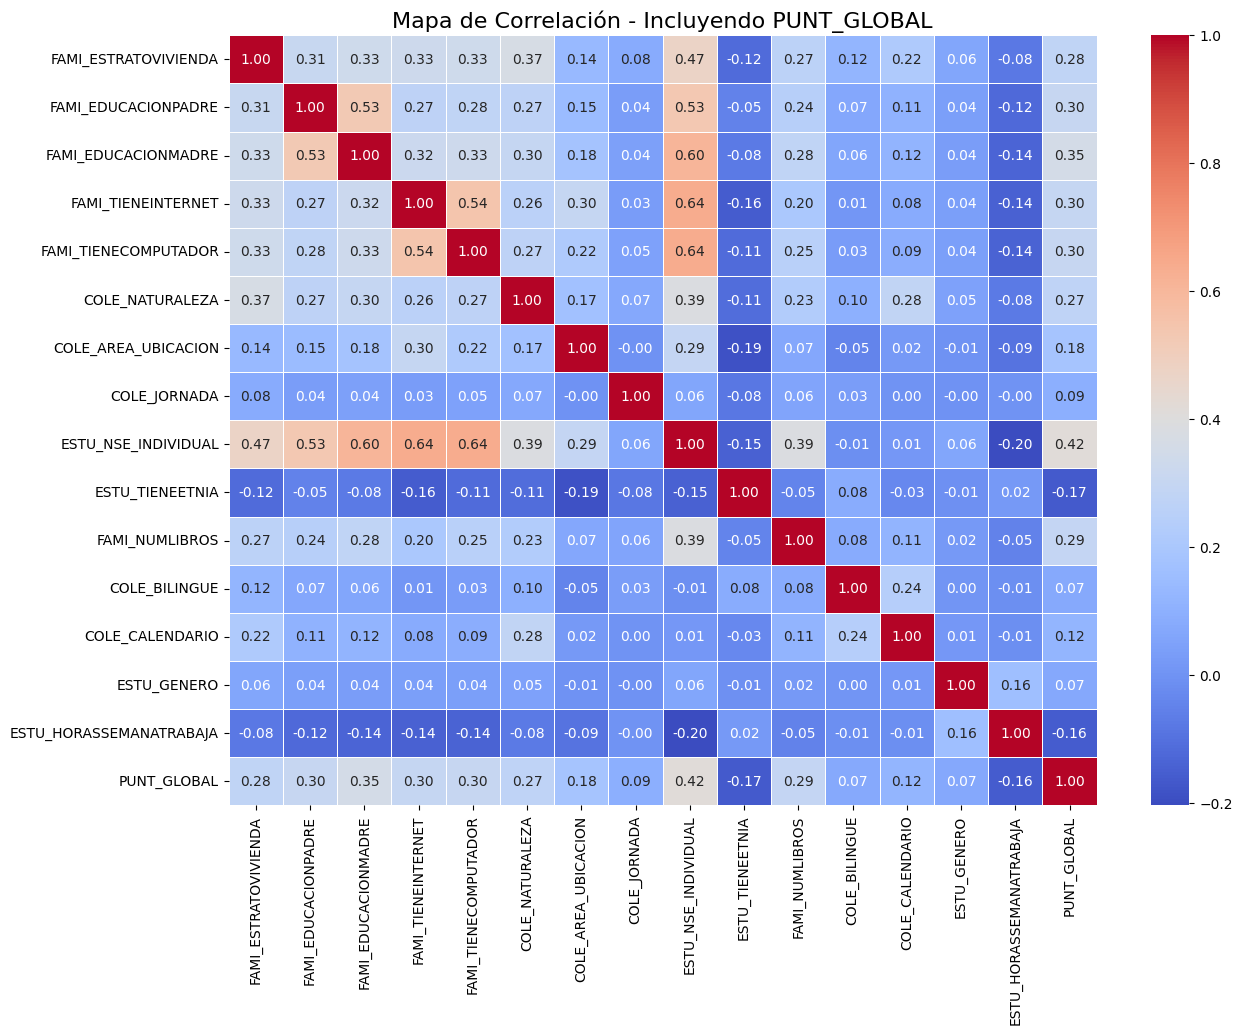

Correlaciones con PUNT_GLOBAL (ordenadas):
PUNT_GLOBAL                1.000000
ESTU_NSE_INDIVIDUAL        0.416553
FAMI_EDUCACIONMADRE        0.353779
FAMI_EDUCACIONPADRE        0.303344
FAMI_TIENECOMPUTADOR       0.300889
FAMI_TIENEINTERNET         0.297274
FAMI_NUMLIBROS             0.293051
FAMI_ESTRATOVIVIENDA       0.277311
COLE_NATURALEZA            0.272933
COLE_AREA_UBICACION        0.181956
COLE_CALENDARIO            0.115812
COLE_JORNADA               0.094985
COLE_BILINGUE              0.074940
ESTU_GENERO                0.072642
ESTU_HORASSEMANATRABAJA   -0.158017
ESTU_TIENEETNIA           -0.165332
Name: PUNT_GLOBAL, dtype: float64


In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Calcular matriz de correlación ---
corr = df_encoded.corr(numeric_only=True)

# --- Heatmap con valores incluidos ---
plt.figure(figsize=(14,10))
sns.heatmap(
    corr, 
    cmap="coolwarm", 
    annot=True,      # mostrar valores
    fmt=".2f",       # 2 decimales
    linewidths=0.5, 
    cbar=True
)
plt.title("Mapa de Correlación - Incluyendo PUNT_GLOBAL", fontsize=16)
plt.show()

# --- Correlación con la variable objetivo ---
corr_target = corr["PUNT_GLOBAL"].sort_values(ascending=False)
print("Correlaciones con PUNT_GLOBAL (ordenadas):")
print(corr_target)


In [166]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# --- 1. Seleccionar variables ---
features = [
   "ESTU_NSE_INDIVIDUAL",
    "FAMI_EDUCACIONMADRE",
    "FAMI_EDUCACIONPADRE",
    "FAMI_TIENECOMPUTADOR",
    "FAMI_TIENEINTERNET",
    "FAMI_NUMLIBROS",
    "FAMI_ESTRATOVIVIENDA",
    "COLE_NATURALEZA"
]

X = df_encoded[features]
y = df_encoded["PUNT_GLOBAL"]

# --- 2. Separar train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# --- 3. Crear y entrenar modelo ---
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# --- 4. Predicciones ---
y_pred = modelo.predict(X_test)

# --- 5. Métricas ---
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Resultados del modelo de Regresión Lineal")
print("-----------------------------------------")
print(f"Coeficientes: {dict(zip(features, modelo.coef_))}")
print(f"Intercepto: {modelo.intercept_:.2f}")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")


Resultados del modelo de Regresión Lineal
-----------------------------------------
Coeficientes: {'ESTU_NSE_INDIVIDUAL': 3.7985041564646593, 'FAMI_EDUCACIONMADRE': 2.845148248126569, 'FAMI_EDUCACIONPADRE': 1.4904245391378252, 'FAMI_TIENECOMPUTADOR': 7.23093027244492, 'FAMI_TIENEINTERNET': 9.232739514101963, 'FAMI_NUMLIBROS': 0.212327144500275, 'FAMI_ESTRATOVIVIENDA': 2.6310301446998237, 'COLE_NATURALEZA': 11.101721016788062}
Intercepto: 190.60
R²: 0.2241
RMSE: 43.62


In [167]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# --- 1. Seleccionar variables ---
features = [
    "ESTU_NSE_INDIVIDUAL",
    "FAMI_EDUCACIONMADRE",
    "FAMI_EDUCACIONPADRE",
    "FAMI_TIENECOMPUTADOR",
    "FAMI_TIENEINTERNET",
    "FAMI_NUMLIBROS",
    "FAMI_ESTRATOVIVIENDA",
    "COLE_NATURALEZA"
]

X = df_encoded[features]
y = df_encoded["PUNT_GLOBAL"]

# --- 2. Separar train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# --- 3. Crear Random Forest con mejores hiperparámetros ---
best_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# --- 4. Entrenar el modelo ---
best_rf.fit(X_train, y_train)

# --- 5. Predicciones ---
y_pred = best_rf.predict(X_test)

# --- 6. Métricas ---
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Resultados del Random Forest final")
print("----------------------------------")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

# --- 7. Importancia de variables ---
importances = best_rf.feature_importances_
for f, imp in zip(features, importances):
    print(f"{f}: {imp:.4f}")


Resultados del Random Forest final
----------------------------------
R²: 0.2686
RMSE: 42.35
ESTU_NSE_INDIVIDUAL: 0.1812
FAMI_EDUCACIONMADRE: 0.2256
FAMI_EDUCACIONPADRE: 0.1459
FAMI_TIENECOMPUTADOR: 0.0871
FAMI_TIENEINTERNET: 0.0989
FAMI_NUMLIBROS: 0.1118
FAMI_ESTRATOVIVIENDA: 0.0714
COLE_NATURALEZA: 0.0781


## Fase 2: identificar características y relaciones en las variables

En esta fase realizarás análisis descriptivo para identificar posibles patrones o relaciones entre las variables de interés para la problemática planteada. Además, expondrás estadísticas descriptivas y visualizaciones para concluir al respecto de los patrones y las relaciones identificadas. Finalmente, elegirás el segmento de los datos sobre el cual profundizarás con tu análisis (este puede ser, o no, igual al seleccionado anteriormente).

Pautas generales:

* Calcular estadísticas descriptivas básicas (por lo menos, media/mediana y varianza/desviación) para cada variable sociodemográfica relevante en el contexto del problema.
* Utilizar librerías especializadas (ej., `matplotlib`, `seaborn`, etc.) para inspeccionar visualmente variables de interés. Los métodos `distplot`, `pairplot`, `boxplot`, o `violinplot`, entre otros, pueden ser útiles.
* Utilizar el método `groupby` de `pandas`, en conjunto con métodos de visualización, puede proveer evidencia del impacto de las variables sociodemográficas de interés sobre el desempeño de los estudiantes en la prueba.

Preguntas guía:

* ¿Hay patrones de interés en las distribuciones de las variables o en las relaciones entre ellas?
* ¿Consideras que existe algún impacto significativo de variables sociodemográficas en los puntajes globales o por área?
* ¿Sobre cuáles variables harías un análisis más profundo?

In [ ]:
# Implementa tu respuesta en esta celda


## Fase 3: abordar relación variables-desempeño a través de un modelo

En esta fase propondrás, implementarás y reportarás el desempeño de uno o más modelos (al menos uno predictivo) que busquen explicar las relaciones entre factores sociodemográficos y el desempeño en la prueba. Además, concluirás con respecto a la validez de al menos un modelo y los posibles hallazgos que se podrían reportar para el *stakeholder*.

Pautas generales:

* Seleccionar variables y proponer modelos acordes a estas y al contexto del problema.
* Utilizar librerías especializadas (ej., `statsmodels`, `sklearn`, etc.) para indagar sobre los aspectos que contribuyen al éxito de los estudiantes. Los módulos correspondientes a regresión lineal y regresión logística pueden ser útiles.
* Asegurar el cumplimiento de los supuestos y buenas prácticas de cada modelo.
* Utilizar las métricas de evaluación de desempeño (disponibles en las librerías especilizadas), para concluir sobre la validez de los modelos propuestos.

Preguntas guía:

* ¿Existe algún sub-conjunto de variables socio-demográficas que explique razonablemente bien el desempeño de los estudiantes en la prueba?

## Fase 4

Deberás elegir y realizar una de las dos alternativas que se encuentran a continuación.

### Alternativa 1: desarrollar una herramienta interactiva de análisis

En esta fase desarrollarás, a partir de alguno de los análisis realizados, una herramienta interactiva que sea relevante en el contexto del problema, acompañada de las instrucciones necesarias para que un usuario la pueda utilizar.

Pautas generales:

* Seleccionar uno de los análisis previos que pueda verse enriquecido con alguna característica de interactividad.
* Seleccionar el/los parámetro(s) que el usuario podrá cambiar.
* Desarrollar las funciones que se deben ejecutar con cada acción del usuario.
* Utilizar una librería especializada (ej., `ipywidgets`, `panel`, etc.) para implementar la herramienta.

Preguntas guía:

* ¿Cuál o cuáles preguntas podrá hacerle el usuario a la herramienta y cómo aporta la respuesta al análisis?
* ¿Qué aprendizajes clave puede explorar u obtener el usuario con esta herramienta?

In [ ]:
# Implementa tu respuesta en esta celda}


### Alternativa 2: registrar en bases de datos relacionales con PySpark

En esta fase desarrollarás, a partir de alguno de los análisis realizados, un _script_ que sea relevante en el contexto del problema, acompañado de las instrucciones necesarias para que un usuario lo pueda ejecutar.

Pautas generales:

* Cargar en una base de datos relacional (tipo SQL) el segmento de los datos sobre el cual profundizaste en tu anális, utilizando una tabla distinta para cada categoría de campos. Por ejemplo, una categoría puedes ser información del colegio; en cuyo caso, una tabla debería contener un registro único para cada colegio y todos los campos asociados.

* Los campos, a excepción de los identificadores, deben existir en un única tabla.

* Cada registro debe existir una única vez en su respectiva tabla.

* Cada registro debe tener un identificador único en su tabla, el cual establece una relación entre tablas.

* Seleccionar uno de los modelos predictivos implementados.

* Crear en la base de datos relacional una tabla que contenga únicamente los identificadores del registro y la predicción de la variable de respuesta hecha por el modelo.

* Desarrollar _queries_ de SQL según las siguientes indicaciones y concluir acerca de los resultados:
    * Un _query_ que seleccione todos registros y los agregue en una única tabla. Para esto debes relacionar las tablas por su identificador, utilizando el método `JOIN`.
    * Un _query_ que contenga el puntaje promedio de los estudiantes, agrupado por año y por colegio.
    * Distintos _queries_ que calculen medidas de error de predicción del modelo a partir de los datos reales y las predicciones respectivas. Debes reportar el error para cada registro, el error total de los registros de entrenamiento y el error total de los registros de prueba.
    * Haz dos _queries_ adicionales que resulten interesantes.

Preguntas guía:

* ¿Cómo aporta la segmentación de los datos en categorías de campos al manejo de los datos?
* ¿Qué filtros y agrupaciones podemos aplicar sobre los datos con el fin de obtener información relevante?

In [ ]:
# Implementa tu respuesta en esta celda


## Referencias

*  J. VanderPlas (2016) *Python Data Science Handbook: Essential Tools for Working with Data* O'Reilly Media, Inc.
*  scikit-learn developers . (2020). Demo of DBSCAN clustering algorithm. 11 Diciembre 2020, de scikit-learn <br> https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html#sphx-glr-auto-examples-cluster-plot-dbscan-py

## Créditos

__Autores__: Camilo Hernando Gómez Castro, Alejandro Mantilla Redondo, Jose Fernando Barrera de Plaza, Diego Alejandro Cely Gómez.

__Fecha última actualización__: 29/09/2022